# Topic modeling des verbatims en santé mentale

Ce notebook illustre la pipeline de topic modeling mise en œuvre dans le cadre du stage.
Les données brutes sont *confidentielles* et ne sont pas fournies dans le dépôt GitHub
(RGPD). Le code ci-dessous suppose que le fichier anonymisé est placé dans `data/raw/`.

In [ ]:
import pandas as pd
import numpy as np

# Chargement des données brutes (fichier NON inclus dans le dépôt GitHub pour des raisons de confidentialité)
# Le fichier doit être placé manuellement dans data/raw/.

df = pd.read_excel("MyData/toutes_colonnes_corrigees_ultrafine.xlsx")

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud
from hdbscan import HDBSCAN
from umap import UMAP
import matplotlib.pyplot as plt
import spacy
import string

# Load spaCy French model
nlp = spacy.load("fr_core_news_md")

def generer_BERTopic(df, colonnes, langue_modele='distiluse-base-multilingual-cased-v1',
                     min_topic_size=5, n_topics=None, n_words_cloud=15):
    """
    Entraîne un modèle BERTopic sur un sous-ensemble de colonnes textuelles.

    Paramètres
    ----------
    df : pandas.DataFrame
        DataFrame contenant les réponses textuelles brutes.
    colonnes : list of str
        Noms des colonnes à fusionner pour construire les documents.
    langue_modele : str
        Nom du modèle SentenceTransformer utilisé pour les embeddings.
    min_topic_size : int
        Taille minimale des clusters HDBSCAN / topics BERTopic.
    n_topics : int ou None
        Nombre cible de topics (paramètre `nr_topics` de BERTopic). `None` = laissé en auto.
    n_words_cloud : int
        Nombre de mots-clés affichés dans les nuages de mots.

    Retourne
    --------
    topic_model : BERTopic
        Modèle BERTopic entraîné.
    topics : list[int]
        Topic assigné à chaque document.
    probs : list[float]
        Probabilité d'appartenance au topic pour chaque document.
    df_resultats : pandas.DataFrame
        Tableau contenant le texte nettoyé, le topic et la probabilité.
    embeddings : np.ndarray
        Matrice des embeddings des documents.
    """

    # 1. Fusion des colonnes
    textes = df[colonnes].dropna(how='all').astype(str).apply(lambda row: ' '.join(row), axis=1)

    def nettoyer_texte(txt):
        txt = txt.translate(str.maketrans('', '', string.punctuation))
        doc = nlp(txt.lower())
        return ' '.join([token.lemma_ for token in doc 
                         if not token.is_stop and not token.is_punct
                         and token.lemma_ != '-PRON-' and token.pos_ in ['NOUN', 'ADJ']
                        ])


    textes_nettoyes = textes.apply(nettoyer_texte)

    # 2. Nettoyage supplémentaire
    textes_nettoyes = textes_nettoyes.drop_duplicates()
    textes_nettoyes = textes_nettoyes[textes_nettoyes.str.split().str.len() >= 3]
    textes_nettoyes = textes_nettoyes[~textes_nettoyes.str.fullmatch(r"\d+", na=False)]

    # 3. Embeddings
    model = SentenceTransformer(langue_modele)
    embeddings = model.encode(textes_nettoyes.tolist(), show_progress_bar=True)

    # 4. Stopwords + vectorizer
    stopwords_perso = [
        "je", "ne", "pas", "plus", "que", "dans", "de", "des", "les", "pour",
        "c'est", "il", "elle", "ils", "elles", "sur", "avec", "le", "la", "et", "est",
        "en", "au", "aux", "à", "du", "un", "une", "mes", "tes", "ma", "ta", "on", 'jai', 'nan', 'cest', 'ner', 'quil', 'quils', "faire", "sentir", "mettre", "voir", "arriver", "penser", "savoir", "devoir", "pouvoir", "vouloir"

    ]
    vectorizer_model = CountVectorizer(stop_words=stopwords_perso)

    # 5. UMAP pour réduire la dimension
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine')

    # 6. Clustering
    hdbscan_model = HDBSCAN(min_cluster_size=2, min_samples=3, metric='euclidean')


    # 7. Modèle BERTopic
    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        embedding_model=model,
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        min_topic_size=min_topic_size,
        nr_topics=n_topics,
        top_n_words=n_words_cloud,
        language="french"
    )

    topics, probs = topic_model.fit_transform(textes_nettoyes.tolist(), embeddings)

    print(topic_model.get_topic_info())

    df_resultats = pd.DataFrame({
    "Texte": textes_nettoyes,
    "Topic": topics,
    "Probabilité": probs
})

    # 9. Nuages de mots
    for topic_num in topic_model.get_topics().keys():
        if topic_num == -1:
            continue
        topic_words = topic_model.get_topic(topic_num)[:n_words_cloud]
        freq_dict = {word: score for word, score in topic_words}
        wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {topic_num}", fontsize=14)
        plt.tight_layout()
        plt.show()

    return topic_model, topics, probs, df_resultats, embeddings


## Métrique d'évaluation

In [ ]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import normalize


def calculer_coherence_bertopic(topic_model, textes_nettoyes):
    """
    Calcule la cohérence thématique globale C_v des topics d'un modèle BERTopic.

    La cohérence C_v mesure la co-occurrence des mots d'un même topic dans les documents.
    Les valeurs sont généralement comprises entre 0 et 1 (plus c'est élevé, mieux c'est).

    Paramètres
    ----------
    topic_model : BERTopic
        Modèle entraîné.
    textes_nettoyes : iterable of str
        Textes prétraités (tokens séparés par des espaces).

    Retourne
    --------
    float
        Score de cohérence globale C_v.
    """
    # Récupérer les topics sous forme de liste de mots
    topic_words = [
        [word for word, _ in topic_model.get_topic(topic)]
        for topic in topic_model.get_topics().keys() if topic != -1
    ]

    # Créer corpus Gensim
    tokenized_texts = [text.split() for text in textes_nettoyes]
    dictionary = Dictionary(tokenized_texts)
    corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

    # Modèle de cohérence
    coherence_model = CoherenceModel(topics=topic_words,
                                     texts=tokenized_texts,
                                     dictionary=dictionary,
                                     coherence='c_v')
    score = coherence_model.get_coherence()
    print(f"Score de cohérence des topics (c_v) : {score:.4f}")
    return score

def calculer_métriques_clustering(embeddings, cluster_labels):
    """
    Calcule deux métriques classiques de qualité de clustering :

    - Silhouette Score (S), entre -1 et 1 : plus S est proche de 1, mieux les clusters sont séparés.
    - Davies–Bouldin Index (DB) : plus DB est faible, meilleure est la séparation des clusters.

    On ignore les points étiquetés comme bruit (-1) par HDBSCAN.

    Paramètres
    ----------
    embeddings : np.ndarray
        Embeddings des documents (après encodage).
    cluster_labels : array-like
        Labels de cluster (HDBSCAN), avec -1 pour le bruit.

    Retourne
    --------
    silhouette : float or None
    db_index : float or None
    """
    # Retirer les points sans cluster (-1)
    mask = np.array(cluster_labels) != -1
    if sum(mask) < 2 or len(set(np.array(cluster_labels)[mask])) < 2:
        print("Pas assez de données ou de clusters pour les métriques.")
        return None, None

    embeddings_filtrés = normalize(np.array(embeddings)[mask])
    labels_filtrés = np.array(cluster_labels)[mask]

    silhouette = silhouette_score(embeddings_filtrés, labels_filtrés)
    db_index = davies_bouldin_score(embeddings_filtrés, labels_filtrés)

    print(f"Silhouette Score : {silhouette:.4f}")
    print(f"Davies-Bouldin Index : {db_index:.4f}")
    return silhouette, db_index


In [ ]:
# ============================
# Évaluation globale du modèle
# ============================

# Cohérence thématique C_v (0–1, plus c'est élevé, plus les mots d'un même topic co-apparaissent)
coherence = calculer_coherence_bertopic(model, df_resultats["Texte"])

# Silhouette et Davies–Bouldin (Silhouette proche de 1 = clusters bien séparés ; DB faible = bonne séparation)
silhouette, db_score = calculer_métriques_clustering(embeddings, df_resultats["Topic"])

print(f"Score de cohérence des topics (c_v) : {coherence:.3f}")
print(f"Silhouette Score    : {silhouette:.3f}")
print(f"Davies-Bouldin index  : {db_score:.3f}")

Score de cohérence des topics (c_v) : 0.3736
Silhouette Score : -0.0169
Davies-Bouldin Index : 2.3633


### Indices d'évaluation 


### Cohérence thématique $C_v$

L'équation de la cohérence thématique est :

$$
C_v = \sum_{m=2}^{M} \sum_{l=1}^{m-1}
\log \frac{D(w_m, w_l) + \varepsilon}{D(w_l)}
$$

où $D(w_m, w_l)$ est le nombre de documents contenant simultanément $w_m$ et $w_l$, 
et $D(w_l)$ le nombre de documents contenant $w_l$. Le terme $\varepsilon$ correspond à un lissage.


### Silhouette Score

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$



### Indice de Davies–Bouldin

$$
DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \ne i} \frac{S_i + S_j}{M_{ij}}
$$

#### Remarque méthodologique sur ces métriques

Les métriques présentées ci-dessus (cohérence $C_v$, silhouette, indice de Davies–Bouldin,
pourcentage de points non classés) ont été calculées afin de disposer d’indicateurs
objectifs de la qualité du clustering et des topics.

Dans le cadre de ce travail de stage, nous n’avons toutefois pas eu le temps
de mener une optimisation systématique de ces métriques (exploration exhaustive
des hyperparamètres, comparaison avec d’autres indices, validation croisée, etc.).
Les résultats doivent donc être interprétés comme des éléments descriptifs et
exploratoires, permettant de comparer quelques configurations raisonnables,
plus que comme une recherche d’“optimum” strict.

In [30]:
def visualiser_clusters_2D_tsne(embeddings, topics):
    from sklearn.manifold import TSNE
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    projection = tsne.fit_transform(embeddings)

    df_proj = pd.DataFrame({
        "x": projection[:, 0],
        "y": projection[:, 1],
        "Topic": topics
    })

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_proj, x="x", y="y", hue="Topic", palette="tab10", s=60, alpha=0.8)
    plt.title("Visualisation 2D des clusters par t-SNE")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


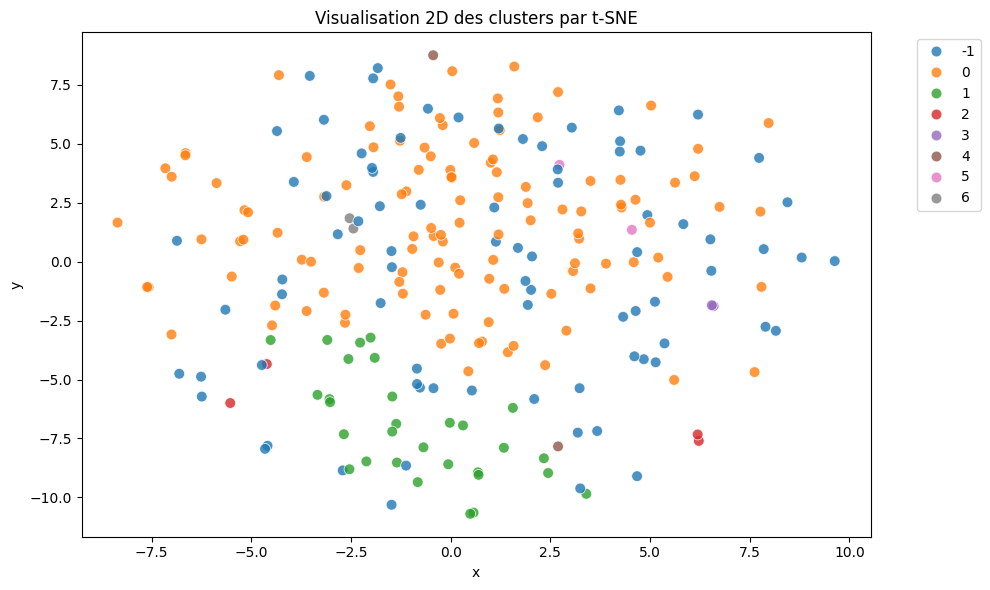

In [31]:
visualiser_clusters_2D_tsne(embeddings, df_resultats["Topic"])

## Comparaison de plusieurs modèles BERTopic

Dans cette section, nous comparons plusieurs configurations du modèle BERTopic
en faisant varier :

- le **nombre de topics cibles** (`nr_topics`) ;
- la **taille minimale des topics** (`min_topic_size` / `min_cluster_size`).

Pour chaque configuration, nous calculons :

- une **cohérence thématique globale** $C_v$,
- un **Silhouette Score** global,
- un **indice de Davies–Bouldin**,
- le **nombre de clusters**,
- le **pourcentage de verbatims non classés** (considérés comme *bruit* par HDBSCAN).

L'objectif est d'identifier une configuration offrant un compromis satisfaisant
entre cohérence thématique, séparation des clusters et taux de bruit.

In [3]:
from comparer_modeles_bertopic import comparer_modeles_bertopic

### Interprétation des métriques

- **Cohérence $C_v$** : plus la valeur est élevée (proche de 1), plus les mots à
  l'intérieur d'un même topic co-apparaissent fréquemment dans les documents.
- **Silhouette Score** $S$ :



$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}
$$

avec $a(i)$ la distance moyenne entre un document et les documents de son cluster,
et $b(i)$ la distance minimale avec un autre cluster.



- **Indice de Davies–Bouldin** \(DB\) :


$$
DB = \frac{1}{K} \sum_{i=1}^{K} 
\max_{j \neq i} \frac{S_i + S_j}{M_{ij}}
$$

où $S_i$ est la dispersion interne du cluster $i$ et $M_{ij}$ la distance entre
les centroïdes des clusters $i$ et $j$.



Pour la suite de l'analyse, nous privilégions les configurations présentant :

- une **cohérence C_v élevée**,
- un **Silhouette Score le plus élevé possible**,
- un **indice DB faible**,
- un **pourcentage de verbatims non classés raisonnable**.

In [37]:
results = comparer_modeles_bertopic(df, colonnes=df.columns[:6], n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.365059,0.001970,2.634454,4,25.925926
1,5,3,0.285308,0.038496,2.741764,4,31.275720
2,5,4,0.393874,0.027302,3.443746,4,31.275720
3,5,5,0.352842,-0.010604,3.211299,4,20.987654
4,6,2,0.384723,0.004856,2.654988,5,30.452675
5,6,3,0.362273,-0.017273,3.019841,5,28.395062
6,6,4,0.310727,0.014219,3.028345,5,24.691358
7,6,5,0.359937,0.012833,3.571634,5,23.456790
8,7,2,0.345650,-0.010998,3.077790,3,0.823045
9,7,3,0.382324,0.015156,3.374391,6,31.687243


In [ ]:
#### Ici le meilleur est pour 8 topics et 2 topic min size

## Determination des topics colonne par colonne

### Pensée

In [ ]:
def generer_BERTopic_colonnes(df, colonnes, langue_modele='distiluse-base-multilingual-cased-v1',
                              min_topic_size=5, n_topics=None, n_words_cloud=15):
    from collections import Counter
    from sklearn.feature_extraction.text import CountVectorizer
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt
    import spacy
    import string
    import pandas as pd
    from bertopic import BERTopic
    from sklearn.feature_extraction.text import CountVectorizer
    from sentence_transformers import SentenceTransformer
    from hdbscan import HDBSCAN
    from umap import UMAP

    nlp = spacy.load("fr_core_news_md")
    resultats_colonnes = {}

    def nettoyer_texte(txt):
        txt = txt.translate(str.maketrans('', '', string.punctuation))
        doc = nlp(txt.lower())
        return ' '.join([token.lemma_ for token in doc 
                         if not token.is_stop and not token.is_punct 
                         and token.lemma_ != '-PRON-' and token.pos_ in ['NOUN', 'ADJ']])

    stopwords_perso = [
        "je", "ne", "pas", "plus", "que", "dans", "de", "des", "les", "pour",
        "c'est", "il", "elle", "ils", "elles", "sur", "avec", "le", "la", "et", "est",
        "en", "au", "aux", "à", "du", "un", "une", "mes", "tes", "ma", "ta", "on",
        'jai', 'nan', 'cest', 'ner', 'quil', 'quils', "faire", "sentir", "mettre", "voir",
        "arriver", "penser", "savoir", "devoir", "pouvoir", "vouloir"
    ]
    vectorizer_model = CountVectorizer(stop_words=stopwords_perso)
    model = SentenceTransformer(langue_modele)

    for col in colonnes:
        print(f"\n🔹 Analyse de la colonne : {col}")
        textes = df[col].dropna().astype(str).apply(nettoyer_texte)
        textes = textes.drop_duplicates()
        textes = textes[textes.str.split().str.len() >= 3]
        textes = textes[~textes.str.fullmatch(r"\d+", na=False)]

        if len(textes) < 5:
            print(f"⚠️ Trop peu de textes valides dans la colonne {col}, sautée.")
            continue

        embeddings = model.encode(textes.tolist(), show_progress_bar=False)
        umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine')
        hdbscan_model = HDBSCAN(min_cluster_size=2, min_samples=3, metric='euclidean')

        topic_model = BERTopic(
            vectorizer_model=vectorizer_model,
            embedding_model=model,
            hdbscan_model=hdbscan_model,
            umap_model=umap_model,
            min_topic_size=min_topic_size,
            nr_topics=n_topics,
            top_n_words=n_words_cloud,
            language="french"
        )

        topics, probs = topic_model.fit_transform(textes.tolist(), embeddings)

        # Affichage automatique des topics
        print(topic_model.get_topic_info())

        df_resultats = pd.DataFrame({
            "Texte": textes,
            "Topic": topics,
            "Probabilité": probs
        })

        def generer_wordcloud_topic(topic_model, textes, topic_num, ngram_range=(1, 3), top_n=30):
            docs_topic = [textes[i] for i, t in enumerate(topic_model.topics_) if t == topic_num]
            if not docs_topic:
                return
            vect = CountVectorizer(ngram_range=ngram_range)
            X = vect.fit_transform(docs_topic)
            freqs = dict(zip(vect.get_feature_names_out(), X.toarray().sum(axis=0)))
            wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freqs)
            plt.figure(figsize=(10, 5))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis("off")
            plt.title(f"{col} – Topic {topic_num} – ngram {ngram_range}", fontsize=14)
            plt.tight_layout()
            plt.show()

        for topic_num in topic_model.get_topics().keys():
            if topic_num == -1:
                continue
            generer_wordcloud_topic(topic_model, textes.tolist(), topic_num, ngram_range=(1, 3), top_n=n_words_cloud)
            generer_wordcloud_topic(topic_model, textes.tolist(), topic_num, ngram_range=(2, 3), top_n=n_words_cloud)

        resultats_colonnes[col] = {
            "model": topic_model,
            "topics": topics,
            "probs": probs,
            "df_resultats": df_resultats,
            "embeddings": embeddings
        }

    return resultats_colonnes


In [80]:
results = comparer_modeles_bertopic(df, colonnes=[df.columns[0]], n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.315734,0.031206,3.537008,4,25.806452
1,5,3,0.369209,0.024993,3.609222,4,20.967742
2,5,4,0.348096,0.041120,3.618485,4,19.892473
3,5,5,0.299837,0.039986,3.762022,4,19.354839
4,6,2,0.372646,0.032176,3.311357,5,18.279570
5,6,3,0.362573,0.035176,3.396866,5,25.268817
6,6,4,0.390871,0.036630,2.888222,5,26.344086
7,6,5,0.306234,0.040570,3.177922,5,24.731183
8,7,2,0.346939,0.035494,3.118324,6,26.344086
9,7,3,0.370143,0.040913,2.952706,6,33.333333


#### Essais de paramètres UMAP / HDBSCAN

Exemple : n_neighbors = 12, min_cluster_size = 2, etc.  
(On commente ici les observations qualitatives sur la structure des topics.)

### Emotions

In [81]:
results = comparer_modeles_bertopic(df, colonnes=[df.columns[1]], n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.362237,0.003704,2.086355,4,31.250000
1,5,3,0.311726,0.027549,2.132550,4,19.270833
2,5,4,0.289592,0.008582,2.476744,4,19.791667
3,5,5,0.317382,0.043674,2.745912,4,23.958333
4,6,2,0.412303,0.019491,2.321367,5,20.312500
5,6,3,0.344909,0.045141,2.705928,5,16.666667
6,6,4,0.353988,0.042967,2.741972,5,21.875000
7,6,5,0.337674,0.072467,2.861162,5,26.562500
8,7,2,0.313842,0.045193,2.465198,6,29.687500
9,7,3,0.348618,0.049423,2.065855,6,28.645833


In [ ]:
#### 4 / n = 6, m = 2

### Comportements

In [82]:
results = comparer_modeles_bertopic(df, colonnes=[df.columns[2]], n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.335359,0.032143,2.879930,4,25.595238
1,5,3,0.315150,0.045237,3.405762,4,14.880952
2,5,4,0.297655,0.038281,2.813367,4,28.571429
3,5,5,0.334562,0.046565,3.455700,4,19.642857
4,6,2,0.343756,0.016241,2.923303,5,21.428571
5,6,3,0.361106,0.041160,2.971918,5,15.476190
6,6,4,0.372729,0.043233,2.957504,5,20.238095
7,6,5,0.354569,0.045258,3.186886,5,19.642857
8,7,2,0.439197,0.040585,2.667557,6,22.023810
9,7,3,0.331303,0.053569,2.847436,6,26.785714


In [ ]:
#### 8 / n = 7, m = 2

### Relations

In [83]:
results = comparer_modeles_bertopic(df, colonnes=[df.columns[3]], n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.329634,0.031600,2.634218,4,15.976331
1,5,3,0.314825,0.032011,2.934746,4,7.692308
2,5,4,0.312512,0.024839,2.715011,4,7.692308
3,5,5,0.294938,0.043475,3.631741,3,2.366864
4,6,2,0.373574,0.026200,2.636014,5,15.384615
5,6,3,0.375734,0.052468,2.956627,5,11.834320
6,6,4,0.345745,0.054094,2.779462,5,24.852071
7,6,5,0.302847,0.043241,3.726594,3,0.591716
8,7,2,0.379326,0.054228,2.613348,6,20.118343
9,7,3,0.357185,0.031534,2.662536,6,5.917160


In [ ]:
#### 14 / n = 8, m = 4

### Situations

In [84]:
results = comparer_modeles_bertopic(df, colonnes=[df.columns[4]], n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.278037,0.024379,2.703928,4,31.213873
1,5,3,0.397451,0.050140,3.169456,4,30.635838
2,5,4,0.341273,0.049569,3.107647,4,30.057803
3,5,5,0.391683,0.049126,3.364396,4,26.589595
4,6,2,0.357348,0.027080,2.801414,5,36.416185
5,6,3,0.389731,0.039892,3.070851,5,34.104046
6,6,4,0.394729,0.046040,3.104798,5,24.855491
7,6,5,0.359184,0.051441,3.091116,5,30.057803
8,7,2,0.398525,0.044694,2.866523,6,30.635838
9,7,3,0.371529,0.041166,2.821367,6,27.167630


In [ ]:
#### 18 / n = 10, m = 4

## Determination des topics par groupes de colonne

In [74]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud
from hdbscan import HDBSCAN
from umap import UMAP
import matplotlib.pyplot as plt
import spacy
import string
import pandas as pd

def generer_BERTopic_concat(df, colonnes, langue_modele='distiluse-base-multilingual-cased-v1',
                            min_topic_size=5, n_topics=None, n_words_cloud=15):
    nlp = spacy.load("fr_core_news_md")

    def nettoyer_texte(txt):
        txt = txt.translate(str.maketrans('', '', string.punctuation))
        doc = nlp(txt.lower())
        return ' '.join([token.lemma_ for token in doc 
                         if not token.is_stop and not token.is_punct 
                         and token.lemma_ != '-PRON-' and token.pos_ in ['NOUN', 'ADJ']])

    textes = df[colonnes].dropna(how='all').astype(str).apply(lambda row: ' '.join(row), axis=1)
    textes = textes.dropna().astype(str).apply(nettoyer_texte)
    textes = textes.drop_duplicates()
    textes = textes[textes.str.split().str.len() >= 3]
    textes = textes[~textes.str.fullmatch(r"\d+", na=False)]

    if len(textes) < 5:
        print("⚠️ Trop peu de textes valides pour lancer BERTopic.")
        return None

    model = SentenceTransformer(langue_modele)
    embeddings = model.encode(textes.tolist(), show_progress_bar=True)

    stopwords_perso = [
        "je", "ne", "pas", "plus", "que", "dans", "de", "des", "les", "pour",
        "c'est", "il", "elle", "ils", "elles", "sur", "avec", "le", "la", "et", "est",
        "en", "au", "aux", "à", "du", "un", "une", "mes", "tes", "ma", "ta", "on",
        'jai', 'nan', 'cest', 'ner', 'quil', 'quils', "faire", "sentir", "mettre", "voir",
        "arriver", "penser", "savoir", "devoir", "pouvoir", "vouloir"
    ]
    vectorizer_model = CountVectorizer(stop_words=stopwords_perso)
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine')
    hdbscan_model = HDBSCAN(min_cluster_size=2, min_samples=3, metric='euclidean')

    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        embedding_model=model,
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        min_topic_size=min_topic_size,
        nr_topics=n_topics,
        top_n_words=n_words_cloud,
        language="french"
    )

    topics, probs = topic_model.fit_transform(textes.tolist(), embeddings)

    df_resultats = pd.DataFrame({
        "Texte": textes,
        "Topic": topics,
        "Probabilité": probs
    })

    # ✅ WordClouds avec ngrammes (2,3)
    for topic_num in topic_model.get_topics().keys():
        if topic_num == -1:
            continue
        docs_topic = [textes.tolist()[i] for i, t in enumerate(topic_model.topics_) if t == topic_num]
        if not docs_topic:
            continue
        vect = CountVectorizer(ngram_range=(2, 3), stop_words=stopwords_perso)
        X = vect.fit_transform(docs_topic)
        freqs = dict(zip(vect.get_feature_names_out(), X.toarray().sum(axis=0)))
        wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freqs)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {topic_num} – ngrams (2,3)", fontsize=14)
        plt.tight_layout()
        plt.show()

    return topic_model, topics, probs, df_resultats, embeddings


In [75]:
# Regroupe proprement par index
col_souffrance = df.columns[[0, 1, 2]]
col_contextes = df.columns[[3, 4, 5]]
col_projections = df.columns[[6, 7]]
col_psychotherapie = df.columns[[8, 9]]



### 1. Souffrance psychologique (cognitions, émotions, comportements)

In [86]:
results = comparer_modeles_bertopic(df, colonnes=col_souffrance, n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.340634,0.040615,3.354753,4,38.818565
1,5,3,0.423333,0.016872,2.790594,4,36.708861
2,5,4,0.364220,0.043333,3.165998,4,36.708861
3,5,5,0.351132,0.017914,3.354524,4,17.299578
4,6,2,0.380099,0.021987,3.037505,5,33.755274
5,6,3,0.345667,0.038055,3.184751,5,29.535865
6,6,4,0.316843,0.017325,3.040918,5,26.160338
7,6,5,0.375959,0.029345,3.876612,4,13.502110
8,7,2,0.366900,0.018663,2.697761,6,26.160338
9,7,3,0.338176,0.006779,2.976552,6,29.957806


In [ ]:
#### 21 / n = 12, m = 3

### 2. Souffrance relationnelle et contextuelle

In [87]:
results = comparer_modeles_bertopic(df, colonnes=col_contextes, n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.306460,0.058071,2.772416,4,28.761062
1,5,3,0.288447,0.051364,2.312012,2,1.327434
2,5,4,0.411568,0.072065,2.975713,4,40.265487
3,5,5,0.351147,0.066094,2.649076,4,25.221239
4,6,2,0.288447,0.050724,2.315855,2,0.442478
5,6,3,0.288447,0.050508,2.315368,2,0.442478
6,6,4,0.384765,0.052197,3.037997,5,25.221239
7,6,5,0.389857,0.034139,3.034448,5,31.415929
8,7,2,0.447160,0.022989,2.452435,6,47.787611
9,7,3,0.335951,0.022359,2.831144,6,32.743363


In [ ]:
#### 8) n = 7, m = 2

### 3. Motivation, changement et obstacle

In [88]:
results = comparer_modeles_bertopic(df, colonnes=col_projections, n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.382205,0.016096,3.320145,4,25.123153
1,5,3,0.383502,0.021148,3.304345,4,25.123153
2,5,4,0.351061,0.039871,3.273448,4,34.975369
3,5,5,0.332196,0.042301,3.369456,4,28.078818
4,6,2,0.323151,0.040431,3.426918,5,29.556650
5,6,3,0.322332,0.044731,3.270479,5,35.467980
6,6,4,0.342135,0.045441,3.329235,5,37.438424
7,6,5,0.368828,0.031615,3.443142,5,24.630542
8,7,2,0.399294,0.031310,2.948728,6,32.019704
9,7,3,0.355598,0.026185,2.649301,6,23.645320


In [ ]:
#### 20) n = 12, m = 2

### 4. Psychothérapie : expérience et bénéfices

In [89]:
results = comparer_modeles_bertopic(df, colonnes=col_psychotherapie, n_topics_list=[5, 6, 7, 8, 10, 12], min_topic_size_list=[2, 3, 4, 5])
results

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

,n_topics,min_topic_size,coherence,silhouette,davies_bouldin,n_clusters,pct_non_classés
0,5,2,0.331536,0.049639,3.253260,4,24.404762
1,5,3,0.334170,0.049440,3.344453,4,28.571429
2,5,4,0.349958,0.057663,3.357908,4,25.595238
3,5,5,0.337624,0.074970,2.803049,4,40.476190
4,6,2,0.401942,0.034269,2.317271,5,27.976190
5,6,3,0.326165,0.040833,2.742221,5,23.809524
6,6,4,0.370596,0.048966,3.082185,5,26.190476
7,6,5,0.365917,0.044232,3.113340,5,32.142857
8,7,2,0.319935,0.045577,2.827997,6,29.166667
9,7,3,0.316599,0.056695,2.813625,6,34.523810


In [ ]:
##### 4) n = 6, m = 2

In [44]:
print(df.columns.size)
df.columns

10


Index(['Au quotidien, quelles sont les pensées (ex : « Je suis nul(le) ») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quelles sont les émotions (ex : tristesse ») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quels sont les comportements (ex : des crises de boulimies) que vous avez qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quelles sont les relations (ex : relations avec votre conjoint(e)) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?',
       'Quelles sont les situations et/ou les évènements (e.g. situations de violences) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?',
       'Au quotidien, quelles sont les autres choses qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?',
       'Que voudriez-vous voir c

In [ ]:
df = pd.read_excel("MyData/toutes_colonnes_corrigees_ultrafine.xlsx", sep = ";")
raw_texts = df[df.columns[0]].dropna().astype(str)

In [ ]:
# ================================================================
# Grid-search UMAP + HDBSCAN + TF-IDF pour optimiser BERTopic
#
# Objectif :
# - explorer plusieurs combinaisons d'hyperparamètres
# - évaluer chaque modèle avec :
#   * cohérence C_v des topics
#   * Silhouette Score
#   * pourcentage de points considérés comme "bruit" par HDBSCAN
# - sélectionner la meilleure configuration pour l'analyse finale.
# ================================================================


import pandas as pd
import spacy
import string
import numpy as np
from itertools import product
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# 1. Chargement des données et modèle de lemme
nlp = spacy.load("fr_core_news_md")

def preprocess(text, custom_stopwords=None):
    text = text.translate(str.maketrans('', '', string.punctuation))
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_punct
              and token.lemma_ != '-PRON-' and token.pos_ in ['NOUN','ADJ']]
    if custom_stopwords:
        tokens = [t for t in tokens if t not in custom_stopwords]
    return ' '.join(tokens)

# Stop-words personnalisés
custom_stopwords = [
    "je","ne","pas","plus","que","dans","de","des","les",
    "pour","c'est","il","elle","ils","elles","sur","avec",
    "le","la","et","est","en","au","aux","à","du","un",
    "une","mes","tes","ma","ta","on","jai","nan","cest","ner",
    "quil","quils","faire","sentir","mettre","voir","arriver",
    "penser","savoir","devoir","pouvoir","vouloir"
]

# Lecture et nettoyage initial
df = pd.read_excel("MyData/toutes_colonnes_corrigees_ultrafine.xlsx")
raw_texts = df[df.columns[0]].dropna().astype(str)
clean_texts = raw_texts.apply(lambda x: preprocess(x, custom_stopwords))
clean_texts = clean_texts[clean_texts.str.split().str.len() >= 5].drop_duplicates()

# 2. Extraction adaptative des collocations
min_df_phrases = max(2, int(len(clean_texts) * 0.01))
common_ngrams = []
if len(clean_texts) >= min_df_phrases * 2:
    try:
        vect_phrases = CountVectorizer(ngram_range=(2,3), stop_words=custom_stopwords, min_df=min_df_phrases)
        X_phr = vect_phrases.fit_transform(clean_texts)
        counts = X_phr.sum(axis=0).A1
        features = vect_phrases.get_feature_names_out()
        common_ngrams = [features[i] for i, c in enumerate(counts) if c >= min_df_phrases]
    except ValueError:
        common_ngrams = []

# 3. Injection des collocations
def inject_ngrams(doc, ngrams):
    text = doc
    for ng in ngrams:
        if ng in doc:
            text += ' ' + ng.replace(' ', '_')
    return text
texts_with_ngrams = clean_texts.apply(lambda x: inject_ngrams(x, common_ngrams)).tolist()
# 4. Préparation pour la cohérence
texts_tokens = [txt.split() for txt in texts_with_ngrams]
dictionary = Dictionary(texts_tokens)

# 5. Embeddings
embed_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = embed_model.encode(texts_with_ngrams, show_progress_bar=True)

# 6. Grid-search UMAP & HDBSCAN
param_grid = {
    'n_neighbors': [10,15,30],
    'min_dist': [0.0,0.1,0.5],
    'min_cluster_size': [2,5,10],
    'min_samples': [1,3]
}
results = []

# 7. Boucle sur toutes les combinaisons d'hyperparamètres (n_neighbors, min_dist, min_cluster_size, min_samples)

for nn, md, mcs, ms in product(*param_grid.values()):
    # Projection et clustering
    umap_model = UMAP(n_neighbors=nn, n_components=2, min_dist=md, metric='cosine')
    hdb_model = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric='euclidean')
    # Vectorisation TF-IDF
    vect_model = TfidfVectorizer(ngram_range=(1,2), stop_words=custom_stopwords, min_df=2)

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdb_model,
        vectorizer_model=vect_model,
        embedding_model=embed_model,
        language='french',
        min_topic_size=5,
        top_n_words=15,
        nr_topics='auto'
    )
    topics, probs = topic_model.fit_transform(texts_with_ngrams, embeddings)

    # Silhouette
    labels = np.array(topics)
    mask = labels != -1
    if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
        sil = silhouette_score(embeddings[mask], labels[mask])
    else:
        sil = np.nan

    # Cohérence via Gensim
    topic_dict = topic_model.get_topics()
    topics_words = [[word for word, _ in topic_dict[t]] for t in topic_dict if t != -1]
    if topics_words:
        cm = CoherenceModel(
            topics=topics_words,
            texts=texts_tokens,
            dictionary=dictionary,
            coherence='c_v'
        )
        coh = cm.get_coherence()
    else:
        coh = np.nan

# Résumé des performances pour cette combinaison d'hyperparamètres
    pct_noise = np.mean(labels == -1)

    results.append({
        'n_neighbors': nn,
        'min_dist': md,
        'min_cluster_size': mcs,
        'min_samples': ms,
        'coherence': coh,
        'silhouette': sil,
        'pct_noise': pct_noise
    })

# 8. Sélection de la meilleure configuration
results_df = pd.DataFrame(results)
best = results_df.sort_values(['coherence','silhouette'], ascending=False).iloc[0]
print("Meilleure config trouvée :", best)

# 9. Entraînement final avec les meilleurs paramètres
best_umap = UMAP(
    n_neighbors=int(best['n_neighbors']),
    n_components=2,
    min_dist=float(best['min_dist']),
    metric='cosine'
)
best_hdb = HDBSCAN(
    min_cluster_size=int(best['min_cluster_size']),
    min_samples=int(best['min_samples']),
    metric='euclidean'
)
final_vect = TfidfVectorizer(ngram_range=(1,2), stop_words=custom_stopwords, min_df=2)
final_model = BERTopic(
    umap_model=best_umap,
    hdbscan_model=best_hdb,
    vectorizer_model=final_vect,
    embedding_model=embed_model,
    language='french',
    min_topic_size=5,
    top_n_words=15,
    nr_topics='auto'
)
# … après le fit_transform …
final_topics, final_probs = final_model.fit_transform(texts_with_ngrams, embeddings)

# Fusion automatique des topics trop fins
# docs, embeddings, topics, probabilities en positionnel
#final_model.reduce_topics(
 #   texts_with_ngrams,
 #   embeddings,
 #   final_topics,
 #   final_probs,
 #   nr_topics="auto"
#)



# 9. Export des topics finaux
df_info = final_model.get_topic_info()
print(df_info)
df_info.to_csv('topics_final.csv', index=False)


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Meilleure config trouvée : n_neighbors         15.000000
min_dist             0.000000
min_cluster_size     5.000000
min_samples          3.000000
coherence            0.432472
silhouette           0.032373
pct_noise            0.219178
Name: 21, dtype: float64
    Topic  Count                                           Name  \
0      -1     35                  -1_peur_pensée_dautre_négatif   
1       0     25                 0_pensée_conscience_monde_peur   
2       1     16                1_vie_normal_personne_quotidien   
3       2     13                        2_an_mère_enfant_parent   
4       3     12           3_temps_long terme_force_comparaison   
5       4     11  4_confiance_merde_chose_négatif_chose négatif   
6       5      8             5_thérapie_trouble_sensation_santé   
7       6      8                   6_temps_journée_fort_travail   
8       7      6                  7_chance_part_incompétent_bon   
9       8      6          8_important_relation_anxieux_jugement   
1

### Limites de l’évaluation quantitative

L’évaluation quantitative par cohérence $C_v$, silhouette et Davies–Bouldin fournit
un premier cadrage de la qualité du modèle. Néanmoins, faute de temps,
l’optimisation fine de ces métriques (recherche plus systématique d’hyperparamètres,
test d’autres fonctions de distance ou d’indices alternatifs) n’a pas été réalisée.

Dans ce contexte, les métriques ont été utilisées comme des repères pour
sélectionner une configuration globalement satisfaisante, en complément
d’une validation avant tout **clinique** et **qualitative** des topics obtenus.